# Controlled Angular Stress Test for SCM-A2G, MP-A2G, and IBM Hardware Validation

This notebook isolates the geometry effect of angular aggregation for one-qubit variational parameters.  
It evaluates Euclidean, circular, A2G-Euclidean, A2G-Circular, MP-A2G, and SCM-A2G on controlled client-angle cases.

The local model used for validation is:
\[
|0\rangle \xrightarrow{R_y(\theta)} \text{measure } Z,
\qquad
\langle Z \rangle = \cos(\theta).
\]

Use the simulator section first. Run the IBM section only after confirming the table is correct.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

OUT_DIR = Path("SCMResults/controlled_angle_stress_test")
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 140)


## 1. Angular utilities and aggregation rules


In [3]:
# ============================================================
# Angle utilities
# ============================================================

def wrap_deg(x):
    """Wrap degrees to [-180, 180)."""
    return (np.asarray(x, dtype=float) + 180.0) % 360.0 - 180.0


def circular_mean_deg(angles_deg, weights):
    """
    Weighted circular mean on S^1.
    Returns the angle in degrees in [-180, 180).
    """
    A = np.deg2rad(np.asarray(angles_deg, dtype=float))
    W = np.asarray(weights, dtype=float)
    W = W / (W.sum() + 1e-12)

    s = np.sum(W * np.sin(A))
    c = np.sum(W * np.cos(A))
    return float(wrap_deg(np.rad2deg(np.arctan2(s, c))))


def weighted_euclidean_mean_deg(angles_deg, weights):
    """
    Ordinary weighted arithmetic mean in R.
    This intentionally ignores angular periodicity.
    """
    A = np.asarray(angles_deg, dtype=float)
    W = np.asarray(weights, dtype=float)
    W = W / (W.sum() + 1e-12)
    return float(np.sum(W * A))


def z_expectation_ideal(theta_deg):
    """
    Ideal simulator expectation for |0> -- Ry(theta) -- measure Z.
    Since Ry(theta)|0> gives <Z> = cos(theta), this is exact.
    """
    return float(np.cos(np.deg2rad(theta_deg)))


# ============================================================
# A2G and proposed midpoint-based updates
# ============================================================

def a2g_euclidean_update_deg(theta_t_deg, client_angles_deg, weights, beta=0.15):
    """
    Conference-style Euclidean A2G:
        theta_bar = sum_i W_i theta_i
        theta_next = theta_t + beta(theta_bar - theta_t)
    No circular wrapping is applied to the direction.
    """
    theta_t_deg = float(theta_t_deg)
    theta_bar = weighted_euclidean_mean_deg(client_angles_deg, weights)
    raw_direction = theta_bar - theta_t_deg
    theta_next = theta_t_deg + beta * raw_direction

    return {
        "theta_target_deg": float(theta_bar),
        "theta_next_deg": float(theta_next),
        "update_from_theta_t_deg": float(beta * raw_direction),
        "raw_direction_deg": float(raw_direction),
    }


def a2g_circular_update_deg(theta_t_deg, client_angles_deg, weights, beta=0.15):
    """
    Conference-style circular A2G:
        theta_bar = circular mean
        direction = wrap(theta_bar - theta_t)
        theta_next = wrap(theta_t + beta * direction)
    """
    theta_t_deg = float(theta_t_deg)
    theta_bar = circular_mean_deg(client_angles_deg, weights)
    direction = float(wrap_deg(theta_bar - theta_t_deg))
    theta_next = float(wrap_deg(theta_t_deg + beta * direction))

    return {
        "theta_target_deg": float(theta_bar),
        "theta_next_deg": theta_next,
        "update_from_theta_t_deg": float(beta * direction),
        "raw_direction_deg": direction,
    }


def one_shot_midpoint_deg(theta_t_deg, client_angles_deg, weights, beta=0.15):
    """
    One-shot midpoint-projected A2G:
        v0 = sum_i W_i wrap(theta_i - theta_t)
        m  = wrap(theta_t + 0.5 beta v0)
        v_m = sum_i W_i wrap(theta_i - m)
        theta_next = wrap(theta_t + beta v_m)
    """
    theta_t_deg = float(theta_t_deg)
    A = np.asarray(client_angles_deg, dtype=float)
    W = np.asarray(weights, dtype=float)
    W = W / (W.sum() + 1e-12)

    v0 = float(np.sum(W * wrap_deg(A - theta_t_deg)))
    midpoint = float(wrap_deg(theta_t_deg + 0.5 * beta * v0))
    v_mid = float(np.sum(W * wrap_deg(A - midpoint)))
    theta_next = float(wrap_deg(theta_t_deg + beta * v_mid))

    return {
        "theta_target_deg": np.nan,
        "theta_next_deg": theta_next,
        "update_from_theta_t_deg": float(wrap_deg(theta_next - theta_t_deg)),
        "raw_direction_deg": v_mid,
        "midpoint_deg": midpoint,
        "v0_deg": v0,
        "v_mid_deg": v_mid,
    }


def scm_midpoint_deg(
    theta_t_deg,
    client_angles_deg,
    weights,
    beta=0.15,
    scm_iters=10,
    scm_solver_relax=0.7,
    tol=1e-8,
):
    """
    Self-consistent midpoint A2G on S^1.

    Fixed-point form:
        u* = beta psi(u*)
        m(u*) = wrap(theta_t + 0.5 u*)
        psi(u*) = sum_i W_i wrap(theta_i - m(u*))
        theta_next = wrap(theta_t + u*)

    The relaxation coefficient stabilizes the fixed-point iteration.
    """
    theta_t_deg = float(theta_t_deg)
    A = np.asarray(client_angles_deg, dtype=float)
    W = np.asarray(weights, dtype=float)
    W = W / (W.sum() + 1e-12)

    v0 = float(np.sum(W * wrap_deg(A - theta_t_deg)))
    u = beta * v0
    psi = v0
    converged = 0

    for r in range(int(scm_iters)):
        midpoint = float(wrap_deg(theta_t_deg + 0.5 * u))
        psi = float(np.sum(W * wrap_deg(A - midpoint)))

        u_fp = beta * psi
        u_new = (1.0 - scm_solver_relax) * u + scm_solver_relax * u_fp

        if abs(float(wrap_deg(u_new - u))) < tol:
            u = float(u_new)
            converged = 1
            break

        u = float(u_new)

    theta_next = float(wrap_deg(theta_t_deg + u))
    midpoint = float(wrap_deg(theta_t_deg + 0.5 * u))
    residual = abs(float(wrap_deg(u - beta * psi)))

    return {
        "theta_target_deg": np.nan,
        "theta_next_deg": theta_next,
        "update_from_theta_t_deg": float(u),
        "raw_direction_deg": float(psi),
        "midpoint_deg": midpoint,
        "v0_deg": v0,
        "scm_residual_deg": residual,
        "scm_converged": int(converged),
        "scm_iters_used": int(r + 1),
    }


def scm_midpoint_trace_deg(
    theta_t_deg,
    client_angles_deg,
    weights,
    beta=0.15,
    scm_iters=10,
    scm_solver_relax=0.7,
    tol=1e-8,
):
    """Return the SCM fixed-point trace for diagnostics."""
    theta_t_deg = float(theta_t_deg)
    A = np.asarray(client_angles_deg, dtype=float)
    W = np.asarray(weights, dtype=float)
    W = W / (W.sum() + 1e-12)

    v0 = float(np.sum(W * wrap_deg(A - theta_t_deg)))
    u = beta * v0
    rows = []

    for r in range(int(scm_iters)):
        midpoint = float(wrap_deg(theta_t_deg + 0.5 * u))
        psi = float(np.sum(W * wrap_deg(A - midpoint)))
        u_fp = beta * psi
        u_new = float((1.0 - scm_solver_relax) * u + scm_solver_relax * u_fp)

        residual = abs(float(wrap_deg(u_new - beta * psi)))
        change = abs(float(wrap_deg(u_new - u)))
        theta_next = float(wrap_deg(theta_t_deg + u_new))

        rows.append({
            "iter": r,
            "u_old_deg": float(u),
            "midpoint_deg": midpoint,
            "psi_midpoint_direction_deg": psi,
            "u_new_deg": u_new,
            "theta_next_deg": theta_next,
            "fixed_point_change_deg": change,
            "scm_residual_deg": residual,
        })

        u = u_new
        if change < tol:
            break

    return pd.DataFrame(rows)


## 2. Controlled client-angle cases


In [4]:
# These cases are designed to test ordinary and wrap-around angular regimes.
# theta_t_deg is the current global angle used by A2G/MP/SCM updates.
# To compare all cases under the same global state, keep theta_t_deg = -170.0.

BETA = 0.15
DEFAULT_THETA_T_DEG = -170.0

CASES = {
    "A_small_cluster_0": {
        "theta_t_deg": DEFAULT_THETA_T_DEG,
        "client_angles_deg": [5.7, -11.5, 2.9],
        "weights": None,
        "note": "Small non-wrap cluster near 0 degrees.",
    },
    "B_wrap_two_clients": {
        "theta_t_deg": DEFAULT_THETA_T_DEG,
        "client_angles_deg": [174.3, -174.3],
        "weights": None,
        "note": "Two-client wrap-around case near +/-180 degrees.",
    },
    "C_mid_spread": {
        "theta_t_deg": DEFAULT_THETA_T_DEG,
        "client_angles_deg": [-85.9, 0.0, 85.9],
        "weights": None,
        "note": "Symmetric mid-spread case.",
    },
    "D_wrap_three": {
        "theta_t_deg": DEFAULT_THETA_T_DEG,
        "client_angles_deg": [168.5, -171.4, 177.1],
        "weights": None,
        "note": "Three-client wrap-around cluster near +/-180 degrees.",
    },
}

def get_case_arrays(case_cfg):
    A = np.asarray(case_cfg["client_angles_deg"], dtype=float)
    if case_cfg["weights"] is None:
        W = np.ones(len(A), dtype=float) / len(A)
    else:
        W = np.asarray(case_cfg["weights"], dtype=float)
        W = W / W.sum()
    return A, W


## 3. Simulator-only target table: Euclidean versus circular means


In [5]:
target_rows = []

for case_name, cfg in CASES.items():
    A, W = get_case_arrays(cfg)

    theta_euc = weighted_euclidean_mean_deg(A, W)
    theta_circ = circular_mean_deg(A, W)

    client_z = np.array([z_expectation_ideal(a) for a in A], dtype=float)

    target_rows.append({
        "case": case_name,
        "K_clients": len(A),
        "angles_deg": ", ".join(f"{x:.1f}" for x in A),
        "method": "Euclidean_mean",
        "theta_deg": theta_euc,
        "Z_sim_ideal": z_expectation_ideal(theta_euc),
        "client_Z_mean": client_z.mean(),
        "client_Z_min": client_z.min(),
        "client_Z_max": client_z.max(),
        "note": cfg["note"],
    })

    target_rows.append({
        "case": case_name,
        "K_clients": len(A),
        "angles_deg": ", ".join(f"{x:.1f}" for x in A),
        "method": "Circular_mean",
        "theta_deg": theta_circ,
        "Z_sim_ideal": z_expectation_ideal(theta_circ),
        "client_Z_mean": client_z.mean(),
        "client_Z_min": client_z.min(),
        "client_Z_max": client_z.max(),
        "note": cfg["note"],
    })

target_table = pd.DataFrame(target_rows)
target_table["abs_theta_deg"] = np.abs(target_table["theta_deg"])
target_table.to_csv(OUT_DIR / "controlled_target_mean_simulator.csv", index=False)

display(target_table.round(6))
print("Saved:", OUT_DIR / "controlled_target_mean_simulator.csv")


,case,K_clients,angles_deg,method,theta_deg,Z_sim_ideal,client_Z_mean,client_Z_min,client_Z_max,note,abs_theta_deg
0,A_small_cluster_0,3,"5.7, -11.5, 2.9",Euclidean_mean,-0.966667,0.999858,0.991233,0.979925,0.998719,Small non-wrap cluster near 0 degrees.,0.966667
1,A_small_cluster_0,3,"5.7, -11.5, 2.9",Circular_mean,-0.952791,0.999862,0.991233,0.979925,0.998719,Small non-wrap cluster near 0 degrees.,0.952791
2,B_wrap_two_clients,2,"174.3, -174.3",Euclidean_mean,0.000000,1.000000,-0.995056,-0.995056,-0.995056,Two-client wrap-around case near +/-180 degrees.,0.000000
3,B_wrap_two_clients,2,"174.3, -174.3",Circular_mean,-180.000000,-1.000000,-0.995056,-0.995056,-0.995056,Two-client wrap-around case near +/-180 degrees.,180.000000
4,C_mid_spread,3,"-85.9, 0.0, 85.9",Euclidean_mean,0.000000,1.000000,0.380998,0.071497,1.000000,Symmetric mid-spread case.,0.000000
5,C_mid_spread,3,"-85.9, 0.0, 85.9",Circular_mean,0.000000,1.000000,0.380998,0.071497,1.000000,Symmetric mid-spread case.,0.000000
6,D_wrap_three,3,"168.5, -171.4, 177.1",Euclidean_mean,58.066667,0.528932,-0.989133,-0.998719,-0.979925,Three-client wrap-around cluster near +/-180 degrees.,58.066667
7,D_wrap_three,3,"168.5, -171.4, 177.1",Circular_mean,178.061683,-0.999428,-0.989133,-0.998719,-0.979925,Three-client wrap-around cluster near +/-180 degrees.,178.061683


Saved: SCMResults\controlled_angle_stress_test\controlled_target_mean_simulator.csv


## 4. Simulator-only update table: A2G, MP-A2G, and SCM-A2G


In [6]:
def build_update_table(cases, beta=0.15):
    rows = []

    for case_name, cfg in cases.items():
        theta_t = float(cfg["theta_t_deg"])
        A, W = get_case_arrays(cfg)

        # 1. Plain Euclidean mean
        theta_euc = weighted_euclidean_mean_deg(A, W)

        # 2. A2G Euclidean
        euc_a2g = a2g_euclidean_update_deg(theta_t, A, W, beta=beta)

        # 3. Plain circular mean
        theta_circ = circular_mean_deg(A, W)

        # 4. A2G Circular
        circ_a2g = a2g_circular_update_deg(theta_t, A, W, beta=beta)

        # 5. MP-A2G
        mp = one_shot_midpoint_deg(theta_t, A, W, beta=beta)

        # 6. SCM-A2G
        scm = scm_midpoint_deg(theta_t, A, W, beta=beta, scm_iters=10, scm_solver_relax=0.7)

        method_rows = [
            {
                "case": case_name,
                "method": "Euclidean_mean",
                "theta_t_deg": theta_t,
                "theta_target_deg": theta_euc,
                "theta_deg": theta_euc,
                "update_from_theta_t_deg": theta_euc - theta_t,
                "raw_direction_deg": theta_euc - theta_t,
                "midpoint_deg": np.nan,
                "scm_residual_deg": np.nan,
                "notes": "ordinary weighted mean; ignores circular periodicity",
            },
            {
                "case": case_name,
                "method": "A2G_Euclidean",
                "theta_t_deg": theta_t,
                "theta_target_deg": euc_a2g["theta_target_deg"],
                "theta_deg": euc_a2g["theta_next_deg"],
                "update_from_theta_t_deg": euc_a2g["update_from_theta_t_deg"],
                "raw_direction_deg": euc_a2g["raw_direction_deg"],
                "midpoint_deg": np.nan,
                "scm_residual_deg": np.nan,
                "notes": "A2G with Euclidean relaxation",
            },
            {
                "case": case_name,
                "method": "Circular_mean",
                "theta_t_deg": theta_t,
                "theta_target_deg": theta_circ,
                "theta_deg": theta_circ,
                "update_from_theta_t_deg": float(wrap_deg(theta_circ - theta_t)),
                "raw_direction_deg": float(wrap_deg(theta_circ - theta_t)),
                "midpoint_deg": np.nan,
                "scm_residual_deg": np.nan,
                "notes": "weighted circular mean; respects angular periodicity",
            },
            {
                "case": case_name,
                "method": "A2G_Circular",
                "theta_t_deg": theta_t,
                "theta_target_deg": circ_a2g["theta_target_deg"],
                "theta_deg": circ_a2g["theta_next_deg"],
                "update_from_theta_t_deg": circ_a2g["update_from_theta_t_deg"],
                "raw_direction_deg": circ_a2g["raw_direction_deg"],
                "midpoint_deg": np.nan,
                "scm_residual_deg": np.nan,
                "notes": "A2G with circular relaxation",
            },
            {
                "case": case_name,
                "method": "MP_A2G",
                "theta_t_deg": theta_t,
                "theta_target_deg": np.nan,
                "theta_deg": mp["theta_next_deg"],
                "update_from_theta_t_deg": mp["update_from_theta_t_deg"],
                "raw_direction_deg": mp["raw_direction_deg"],
                "midpoint_deg": mp["midpoint_deg"],
                "scm_residual_deg": np.nan,
                "notes": "one-shot midpoint-projected update",
            },
            {
                "case": case_name,
                "method": "SCM_A2G",
                "theta_t_deg": theta_t,
                "theta_target_deg": np.nan,
                "theta_deg": scm["theta_next_deg"],
                "update_from_theta_t_deg": scm["update_from_theta_t_deg"],
                "raw_direction_deg": scm["raw_direction_deg"],
                "midpoint_deg": scm["midpoint_deg"],
                "scm_residual_deg": scm["scm_residual_deg"],
                "scm_converged": scm["scm_converged"],
                "scm_iters_used": scm["scm_iters_used"],
                "notes": "proposed self-consistent midpoint update",
            },
        ]

        for row in method_rows:
            row["K_clients"] = len(A)
            row["angles_deg"] = ", ".join(f"{x:.1f}" for x in A)
            row["beta"] = beta
            row["Z_sim_ideal"] = z_expectation_ideal(row["theta_deg"])
            row["distance_to_circular_mean_deg"] = abs(float(wrap_deg(row["theta_deg"] - theta_circ)))
            rows.append(row)

    return pd.DataFrame(rows)


update_table = build_update_table(CASES, beta=BETA)
update_table.to_csv(OUT_DIR / "controlled_update_methods_simulator.csv", index=False)

display(update_table.round(6))
print("Saved:", OUT_DIR / "controlled_update_methods_simulator.csv")


,case,method,theta_t_deg,theta_target_deg,theta_deg,update_from_theta_t_deg,raw_direction_deg,midpoint_deg,scm_residual_deg,notes,K_clients,angles_deg,beta,Z_sim_ideal,distance_to_circular_mean_deg,scm_converged,scm_iters_used
0,A_small_cluster_0,Euclidean_mean,-170.0,-0.966667,-0.966667,169.033333,169.033333,NaN,NaN,ordinary weighted mean; ignores circular periodicity,3,"5.7, -11.5, 2.9",0.15,0.999858,0.013875,NaN,NaN
1,A_small_cluster_0,A2G_Euclidean,-170.0,-0.966667,-144.645000,25.355000,169.033333,NaN,NaN,A2G with Euclidean relaxation,3,"5.7, -11.5, 2.9",0.15,-0.815583,143.692209,NaN,NaN
2,A_small_cluster_0,Circular_mean,-170.0,-0.952791,-0.952791,169.047209,169.047209,NaN,NaN,weighted circular mean; respects angular periodicity,3,"5.7, -11.5, 2.9",0.15,0.999862,0.000000,NaN,NaN
3,A_small_cluster_0,A2G_Circular,-170.0,-0.952791,-144.642919,25.357081,169.047209,NaN,NaN,A2G with circular relaxation,3,"5.7, -11.5, 2.9",0.15,-0.815561,143.690127,NaN,NaN
4,A_small_cluster_0,MP_A2G,-170.0,NaN,-146.546625,23.453375,156.355833,-157.322500,NaN,one-shot midpoint-projected update,3,"5.7, -11.5, 2.9",0.15,-0.834335,145.593834,NaN,NaN
5,A_small_cluster_0,SCM_A2G,-170.0,NaN,-146.413952,23.586048,157.240307,-158.206976,0.000002,proposed self-consistent midpoint update,3,"5.7, -11.5, 2.9",0.15,-0.833056,145.461161,0.0,10.0
6,B_wrap_two_clients,Euclidean_mean,-170.0,0.000000,0.000000,170.000000,170.000000,NaN,NaN,ordinary weighted mean; ignores circular periodicity,2,"174.3, -174.3",0.15,1.000000,180.000000,NaN,NaN
7,B_wrap_two_clients,A2G_Euclidean,-170.0,0.000000,-144.500000,25.500000,170.000000,NaN,NaN,A2G with Euclidean relaxation,2,"174.3, -174.3",0.15,-0.814116,35.500000,NaN,NaN
8,B_wrap_two_clients,Circular_mean,-170.0,-180.000000,-180.000000,-10.000000,-10.000000,NaN,NaN,weighted circular mean; respects angular periodicity,2,"174.3, -174.3",0.15,-1.000000,0.000000,NaN,NaN
9,B_wrap_two_clients,A2G_Circular,-170.0,-180.000000,-171.500000,-1.500000,-10.000000,NaN,NaN,A2G with circular relaxation,2,"174.3, -174.3",0.15,-0.989016,8.500000,NaN,NaN


Saved: SCMResults\controlled_angle_stress_test\controlled_update_methods_simulator.csv


## 5. SCM convergence traces


In [7]:
trace_frames = []

for case_name, cfg in CASES.items():
    A, W = get_case_arrays(cfg)
    trace = scm_midpoint_trace_deg(
        theta_t_deg=cfg["theta_t_deg"],
        client_angles_deg=A,
        weights=W,
        beta=BETA,
        scm_iters=10,
        scm_solver_relax=0.7,
    )
    trace.insert(0, "case", case_name)
    trace_frames.append(trace)

scm_trace_table = pd.concat(trace_frames, ignore_index=True)
scm_trace_table.to_csv(OUT_DIR / "scm_fixed_point_traces.csv", index=False)

display(scm_trace_table.round(8))
print("Saved:", OUT_DIR / "scm_fixed_point_traces.csv")


,case,iter,u_old_deg,midpoint_deg,psi_midpoint_direction_deg,u_new_deg,theta_next_deg,fixed_point_change_deg,scm_residual_deg
0,A_small_cluster_0,0,25.355000,-157.322500,156.355833,24.023862,-145.976137,1.331138e+00,5.704875e-01
1,A_small_cluster_0,1,24.023862,-157.988069,157.021402,23.694406,-146.305594,3.294565e-01,1.411957e-01
2,A_small_cluster_0,2,23.694406,-158.152797,157.186130,23.612865,-146.387135,8.154049e-02,3.494592e-02
3,A_small_cluster_0,3,23.612865,-158.193567,157.226901,23.592684,-146.407316,2.018127e-02,8.649120e-03
4,A_small_cluster_0,4,23.592684,-158.203658,157.236991,23.587689,-146.412311,4.994860e-03,2.140660e-03
5,A_small_cluster_0,5,23.587689,-158.206155,157.239489,23.586453,-146.413547,1.236230e-03,5.298100e-04
6,A_small_cluster_0,6,23.586453,-158.206773,157.240107,23.586147,-146.413853,3.059700e-04,1.311300e-04
7,A_small_cluster_0,7,23.586147,-158.206926,157.240260,23.586071,-146.413929,7.573000e-05,3.245000e-05
8,A_small_cluster_0,8,23.586071,-158.206964,157.240298,23.586053,-146.413947,1.874000e-05,8.030000e-06
9,A_small_cluster_0,9,23.586053,-158.206974,157.240307,23.586048,-146.413952,4.640000e-06,1.990000e-06


Saved: SCMResults\controlled_angle_stress_test\scm_fixed_point_traces.csv


## 6. Optional plots for the paper/appendix


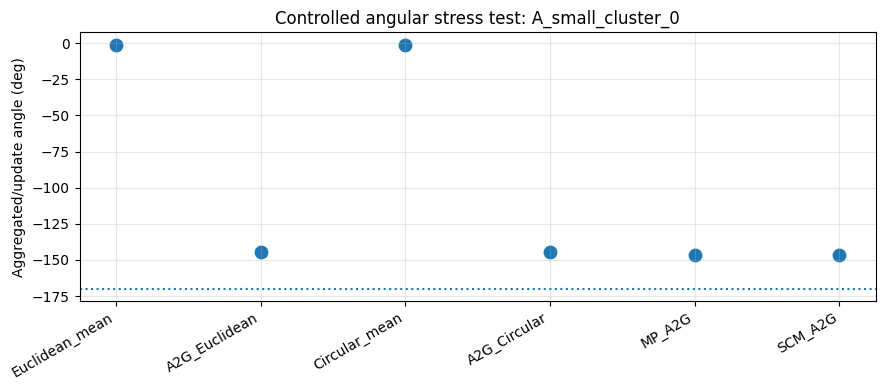

Saved: SCMResults\controlled_angle_stress_test\A_small_cluster_0_method_angles.png


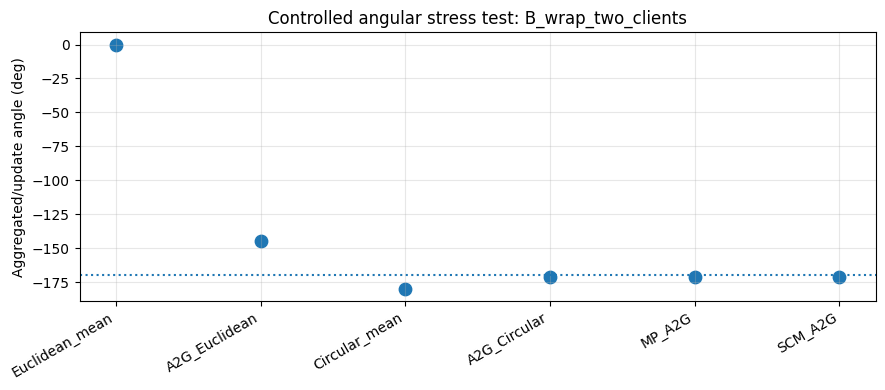

Saved: SCMResults\controlled_angle_stress_test\B_wrap_two_clients_method_angles.png


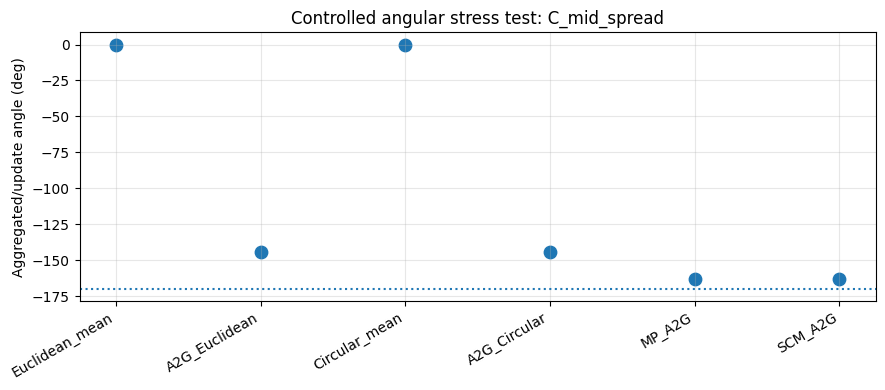

Saved: SCMResults\controlled_angle_stress_test\C_mid_spread_method_angles.png


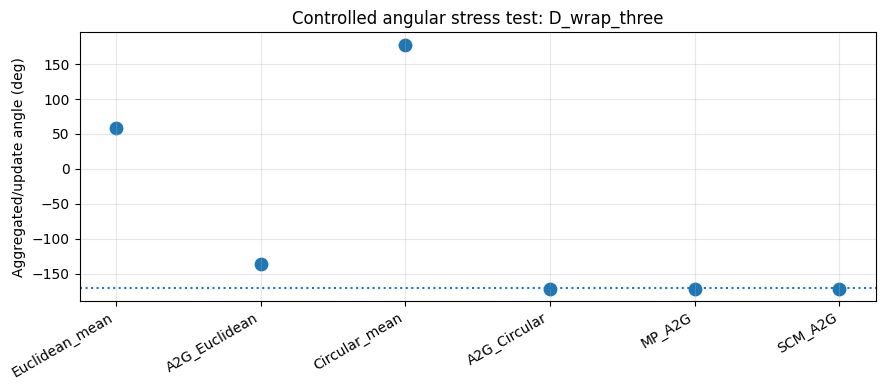

Saved: SCMResults\controlled_angle_stress_test\D_wrap_three_method_angles.png


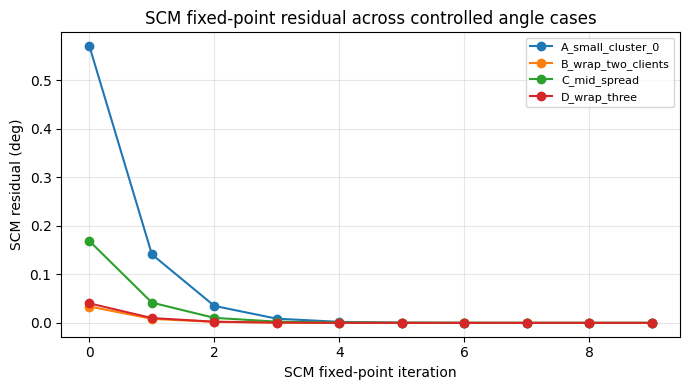

Saved: SCMResults\controlled_angle_stress_test\scm_residual_traces.png


In [8]:
import matplotlib.pyplot as plt

# Plot final theta positions per method for each case.
for case_name in CASES.keys():
    sub = update_table[update_table["case"] == case_name].copy()

    plt.figure(figsize=(9, 4))
    plt.axhline(CASES[case_name]["theta_t_deg"], linestyle=":", linewidth=1.5, label=r"$\theta_t$")
    plt.scatter(sub["method"], sub["theta_deg"], s=80)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Aggregated/update angle (deg)")
    plt.title(f"Controlled angular stress test: {case_name}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = OUT_DIR / f"{case_name}_method_angles.png"
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# Plot SCM residual per case.
plt.figure(figsize=(7, 4))
for case_name, g in scm_trace_table.groupby("case"):
    plt.plot(g["iter"], g["scm_residual_deg"], marker="o", label=case_name)

plt.xlabel("SCM fixed-point iteration")
plt.ylabel("SCM residual (deg)")
plt.title("SCM fixed-point residual across controlled angle cases")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

path = OUT_DIR / "scm_residual_traces.png"
plt.savefig(path, dpi=250, bbox_inches="tight")
plt.show()
print("Saved:", path)


## 7. IBM hardware validation block

Run this section only when:
1. your IBM account is already saved or available through environment configuration;
2. the simulator table above looks correct;
3. you are ready to submit the hardware job.

Do **not** hard-code your IBM token in the notebook. Use `QiskitRuntimeService.save_account(...)` once in a private setup cell or set credentials outside this notebook.


In [10]:
# Set this to True only when you are ready to submit the IBM hardware job.
RUN_IBM = True #False
IBM_BACKEND = "ibm_fez"     # change if needed
IBM_INPUT_TABLE = update_table.copy()

if RUN_IBM:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import SparsePauliOp
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

    def build_ry_z_circuit(theta_deg):
        qc = QuantumCircuit(1)
        qc.ry(np.deg2rad(float(theta_deg)), 0)
        return qc

    def map_observable_to_isa(observable_1q, qc_transpiled):
        # Newer Qiskit accepts num_qubits; older versions may not.
        try:
            return observable_1q.apply_layout(
                qc_transpiled.layout,
                num_qubits=qc_transpiled.num_qubits,
            )
        except TypeError:
            return observable_1q.apply_layout(qc_transpiled.layout)

    def run_ibm_estimator_for_angles(angle_df, backend_name):
        service = QiskitRuntimeService()
        backend = service.backend(backend_name)

        circuits = [build_ry_z_circuit(theta) for theta in angle_df["theta_deg"].values]

        pm = generate_preset_pass_manager(
            optimization_level=1,
            backend=backend,
        )
        transpiled_circuits = pm.run(circuits)

        compile_rows = []
        for (_, row), qc_t in zip(angle_df.iterrows(), transpiled_circuits):
            ops = qc_t.count_ops()
            compile_rows.append({
                "case": row.get("case", ""),
                "method": row.get("method", ""),
                "theta_deg": row["theta_deg"],
                "num_qubits": qc_t.num_qubits,
                "depth": qc_t.depth(),
                "cx_count": int(ops.get("cx", 0)),
                "rz_count": int(ops.get("rz", 0)),
                "sx_count": int(ops.get("sx", 0)),
                "x_count": int(ops.get("x", 0)),
            })

        compile_df = pd.DataFrame(compile_rows)

        observable_1q = SparsePauliOp.from_list([("Z", 1.0)])
        estimator = Estimator(mode=backend)

        pubs = []
        for qc_t in transpiled_circuits:
            obs_t = map_observable_to_isa(observable_1q, qc_t)
            pubs.append((qc_t, obs_t))

        job = estimator.run(pubs)
        result = job.result()

        ibm_z_values = []
        for i in range(len(transpiled_circuits)):
            evs = result[i].data.evs
            ibm_z_values.append(float(np.asarray(evs).reshape(-1)[0]))

        out = angle_df.copy()
        out["backend"] = backend_name
        out["ibm_job_id"] = job.job_id()
        out["Z_ibm"] = ibm_z_values
        out["abs_error"] = np.abs(out["Z_ibm"] - out["Z_sim_ideal"])

        return out, compile_df, job.job_id()

    ibm_df, compile_df, job_id = run_ibm_estimator_for_angles(
        IBM_INPUT_TABLE,
        backend_name=IBM_BACKEND,
    )

    ibm_csv = OUT_DIR / "controlled_update_methods_ibm_hardware.csv"
    compile_csv = OUT_DIR / "controlled_update_methods_ibm_compile.csv"

    ibm_df.to_csv(ibm_csv, index=False)
    compile_df.to_csv(compile_csv, index=False)

    display(ibm_df.round(6))
    display(compile_df)

    print("IBM job id:", job_id)
    print("Saved:", ibm_csv)
    print("Saved:", compile_csv)
else:
    print("RUN_IBM is False. Simulator tables were generated without submitting an IBM job.")


,case,method,theta_t_deg,theta_target_deg,theta_deg,update_from_theta_t_deg,raw_direction_deg,midpoint_deg,scm_residual_deg,notes,K_clients,angles_deg,beta,Z_sim_ideal,distance_to_circular_mean_deg,scm_converged,scm_iters_used,backend,ibm_job_id,Z_ibm,abs_error
0,A_small_cluster_0,Euclidean_mean,-170.0,-0.966667,-0.966667,169.033333,169.033333,NaN,NaN,ordinary weighted mean; ignores circular periodicity,3,"5.7, -11.5, 2.9",0.15,0.999858,0.013875,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,0.999684,0.000173
1,A_small_cluster_0,A2G_Euclidean,-170.0,-0.966667,-144.645000,25.355000,169.033333,NaN,NaN,A2G with Euclidean relaxation,3,"5.7, -11.5, 2.9",0.15,-0.815583,143.692209,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,-0.837109,0.021527
2,A_small_cluster_0,Circular_mean,-170.0,-0.952791,-0.952791,169.047209,169.047209,NaN,NaN,weighted circular mean; respects angular periodicity,3,"5.7, -11.5, 2.9",0.15,0.999862,0.000000,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,0.998675,0.001187
3,A_small_cluster_0,A2G_Circular,-170.0,-0.952791,-144.642919,25.357081,169.047209,NaN,NaN,A2G with circular relaxation,3,"5.7, -11.5, 2.9",0.15,-0.815561,143.690127,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,-0.832061,0.016499
4,A_small_cluster_0,MP_A2G,-170.0,NaN,-146.546625,23.453375,156.355833,-157.322500,NaN,one-shot midpoint-projected update,3,"5.7, -11.5, 2.9",0.15,-0.834335,145.593834,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,-0.845693,0.011358
5,A_small_cluster_0,SCM_A2G,-170.0,NaN,-146.413952,23.586048,157.240307,-158.206976,0.000002,proposed self-consistent midpoint update,3,"5.7, -11.5, 2.9",0.15,-0.833056,145.461161,0.0,10.0,ibm_fez,d8790glg7okc73em0peg,-0.840139,0.007083
6,B_wrap_two_clients,Euclidean_mean,-170.0,0.000000,0.000000,170.000000,170.000000,NaN,NaN,ordinary weighted mean; ignores circular periodicity,2,"174.3, -174.3",0.15,1.000000,180.000000,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,0.997665,0.002335
7,B_wrap_two_clients,A2G_Euclidean,-170.0,0.000000,-144.500000,25.500000,170.000000,NaN,NaN,A2G with Euclidean relaxation,2,"174.3, -174.3",0.15,-0.814116,35.500000,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,-0.834585,0.020470
8,B_wrap_two_clients,Circular_mean,-170.0,-180.000000,-180.000000,-10.000000,-10.000000,NaN,NaN,weighted circular mean; respects angular periodicity,2,"174.3, -174.3",0.15,-1.000000,0.000000,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,-0.983528,0.016472
9,B_wrap_two_clients,A2G_Circular,-170.0,-180.000000,-171.500000,-1.500000,-10.000000,NaN,NaN,A2G with circular relaxation,2,"174.3, -174.3",0.15,-0.989016,8.500000,NaN,NaN,ibm_fez,d8790glg7okc73em0peg,-0.991101,0.002085


,case,method,theta_deg,num_qubits,depth,cx_count,rz_count,sx_count,x_count
0,A_small_cluster_0,Euclidean_mean,-0.966667,156,4,0,2,2,0
1,A_small_cluster_0,A2G_Euclidean,-144.645000,156,4,0,2,2,0
2,A_small_cluster_0,Circular_mean,-0.952791,156,4,0,2,2,0
3,A_small_cluster_0,A2G_Circular,-144.642919,156,4,0,2,2,0
4,A_small_cluster_0,MP_A2G,-146.546625,156,4,0,2,2,0
5,A_small_cluster_0,SCM_A2G,-146.413952,156,4,0,2,2,0
6,B_wrap_two_clients,Euclidean_mean,0.000000,156,0,0,0,0,0
7,B_wrap_two_clients,A2G_Euclidean,-144.500000,156,4,0,2,2,0
8,B_wrap_two_clients,Circular_mean,-180.000000,156,2,0,1,0,1
9,B_wrap_two_clients,A2G_Circular,-171.500000,156,4,0,2,2,0


IBM job id: d8790glg7okc73em0peg
Saved: SCMResults\controlled_angle_stress_test\controlled_update_methods_ibm_hardware.csv
Saved: SCMResults\controlled_angle_stress_test\controlled_update_methods_ibm_compile.csv


## 8. Compact LaTeX export


In [11]:
# Compact table for paper: keep only the most important columns.
compact_cols = [
    "case", "method", "theta_t_deg", "angles_deg",
    "theta_deg", "update_from_theta_t_deg", "Z_sim_ideal",
    "distance_to_circular_mean_deg", "notes"
]

compact_table = update_table[compact_cols].copy()
compact_tex = compact_table.to_latex(
    index=False,
    float_format="%.4f",
    escape=False,
    caption="Controlled angular stress test for Euclidean, circular, MP-A2G, and SCM-A2G aggregation.",
    label="tab:controlled_angular_stress_test",
)

tex_path = OUT_DIR / "controlled_angular_stress_test_table.tex"
tex_path.write_text(compact_tex, encoding="utf-8")

print(compact_tex)
print("Saved:", tex_path)


\begin{table}
\caption{Controlled angular stress test for Euclidean, circular, MP-A2G, and SCM-A2G aggregation.}
\label{tab:controlled_angular_stress_test}
\begin{tabular}{llrlrrrrl}
\toprule
case & method & theta_t_deg & angles_deg & theta_deg & update_from_theta_t_deg & Z_sim_ideal & distance_to_circular_mean_deg & notes \\
\midrule
A_small_cluster_0 & Euclidean_mean & -170.0000 & 5.7, -11.5, 2.9 & -0.9667 & 169.0333 & 0.9999 & 0.0139 & ordinary weighted mean; ignores circular periodicity \\
A_small_cluster_0 & A2G_Euclidean & -170.0000 & 5.7, -11.5, 2.9 & -144.6450 & 25.3550 & -0.8156 & 143.6922 & A2G with Euclidean relaxation \\
A_small_cluster_0 & Circular_mean & -170.0000 & 5.7, -11.5, 2.9 & -0.9528 & 169.0472 & 0.9999 & 0.0000 & weighted circular mean; respects angular periodicity \\
A_small_cluster_0 & A2G_Circular & -170.0000 & 5.7, -11.5, 2.9 & -144.6429 & 25.3571 & -0.8156 & 143.6901 & A2G with circular relaxation \\
A_small_cluster_0 & MP_A2G & -170.0000 & 5.7, -11.5, 2.9 &